# Exploratory Data Analysis #

# 1. Introduction #

### Problem Statement ###
The rapid expansion of AI-related employment has created inconsistent and overlapping job titles across industries, making it difficult for job seekers and analysts to understand how AI roles differ in compensation, experience expectations, work arrangements, and market positioning. This project aims to identify meaningful categories of AI jobs across North America and explain the characteristics that distinguish them.


### List of questions I aim to pursue ###
- How diverse are AI job postings across specializations, expereince, industry, and work arrangement?
- How does compensation differ across AI specializations, experience levels, and work arrangements?
- To what extent do job titles correspond to the underlying characteristics of AI jobs?
- Which technical skills are most associated with different AI specializations and postings?
- How do AI roles differ in terms of employer characteristics and job-market positioning?

In [ ]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from scipy.stats import chi2_contingency
# Show plots inline
%matplotlib inline

In [ ]:
from scipy.stats import chi2_contingency

# do a test to see if chi2_contingency is working
statistic, p_value, dof, expected = chi2_contingency([[10, 20], [20, 40]])

Chi-square statistic: 0.00


In [2]:
# Reading in the data
job_postings = pd.read_csv('../data/processed/wrangled_american_cleaned_job_data.csv')

In [3]:
job_postings.head(3)

,Job Title,Company Name,Company Industry,Company Size,Job Location,Remote / Hybrid / On-site,Country,Salary Range,Experience Level,Employment Type,...,AI Specialization,Education Requirements,Years of Experience Required,Job Description,Posting Date,Benefits Offered,Company Rating,Number of Applicants,Job URL,Data Collection Timestamp
0,AI Agentic Engineer - Multiple USA locations,ClifyX,Technology,"1,001-5,000 employees","Bentonville, AR",Hybrid,United States,"$140,000 - $180,000",Senior,Full-time,...,Generative AI,"Master's in Computer Science, Machine Learning...",5,We are seeking a senior AI Engineer to lead ge...,2026-06-22,"Health insurance, 401(k), Unlimited PTO",4.2,42,https://www.linkedin.com/jobs/view/ai-agentic-...,2026-06-22T11:41:12.537989
1,AI Engineer,Casumo,Technology,"1,001-5,000 employees","Swieqi, Malta",Hybrid,United States,"$140,000 - $180,000",Senior,Full-time,...,Generative AI,"Master's in Computer Science, Machine Learning...",5,We are seeking a senior AI Engineer to lead ge...,2026-06-22,"Health insurance, 401(k), Unlimited PTO",4.2,42,https://mt.linkedin.com/jobs/view/ai-engineer-...,2026-06-22T11:41:12.540233
2,"Applied AI Engineer, Global Public Sector",Scale AI,Technology,"1,001-5,000 employees","Doha, Qatar",Hybrid,United States,"$140,000 - $180,000",Senior,Full-time,...,Generative AI,"Master's in Computer Science, Machine Learning...",5,We are seeking a senior AI Engineer to lead ge...,2026-06-22,"Health insurance, 401(k), Unlimited PTO",4.2,42,https://qa.linkedin.com/jobs/view/applied-ai-e...,2026-06-22T11:41:12.545900


In [4]:
print(job_postings.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8766 entries, 0 to 8765
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Job Title                       8766 non-null   object 
 1   Company Name                    8766 non-null   object 
 2   Company Industry                8766 non-null   object 
 3   Company Size                    8766 non-null   object 
 4   Job Location                    8766 non-null   object 
 5   Remote / Hybrid / On-site       8766 non-null   object 
 6   Country                         8766 non-null   object 
 7   Salary Range                    8766 non-null   object 
 8   Experience Level                8766 non-null   object 
 9   Employment Type                 8766 non-null   object 
 10  Required Skills                 8766 non-null   object 
 11  Programming Languages Required  8766 non-null   object 
 12  AI Specialization               87

In [5]:
print(job_postings.describe())

       Years of Experience Required  Company Rating  Number of Applicants
count                   8766.000000     8766.000000           8766.000000
mean                       4.897102        4.146247            224.429500
std                        3.169722        0.434178            130.008835
min                        0.000000        3.400000              0.000000
25%                        3.000000        3.800000            113.000000
50%                        4.000000        4.200000            223.000000
75%                        7.000000        4.500000            337.000000
max                       12.000000        4.900000            450.000000


## Tackling Question 1 ##

How diverse are AI job postings across specializations, experience, industry, and work arrangement?

A couple hypotheses I have going into this:
- Different AI specializations have noticeably different experience-level distributions.
- AI roles are not evenly distributed across industries.

In [6]:
# Let's find differences between categorical variables. We will use bar charts to visualize the distribution of these categorical variables.
# First we'll collect all the categorical variables in a list and then loop through them to create bar charts for each variable.
categorical_columns = job_postings.select_dtypes(include='object').columns.tolist()
print("Categorical Columns:", categorical_columns)

Categorical Columns: ['Job Title', 'Company Name', 'Company Industry', 'Company Size', 'Job Location', 'Remote / Hybrid / On-site', 'Country', 'Salary Range', 'Experience Level', 'Employment Type', 'Required Skills', 'Programming Languages Required', 'AI Specialization', 'Education Requirements', 'Job Description', 'Posting Date', 'Benefits Offered', 'Job URL', 'Data Collection Timestamp']


In [7]:
# I also want to get rid of some that won't be useful for our analysis for this question. We'll keep 'AI Specialization', 'Experience Level', 'Company Industry', 'Remote / Hybrid / On-site', and 'Employment Type'
seiw_columns = ['AI Specialization', 'Experience Level', 'Company Industry', 'Remote / Hybrid / On-site', 'Employment Type']

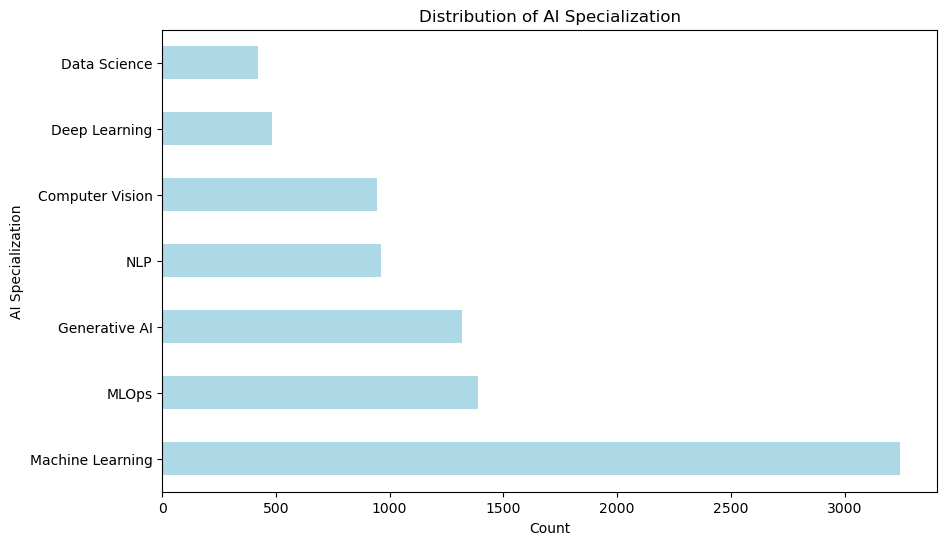

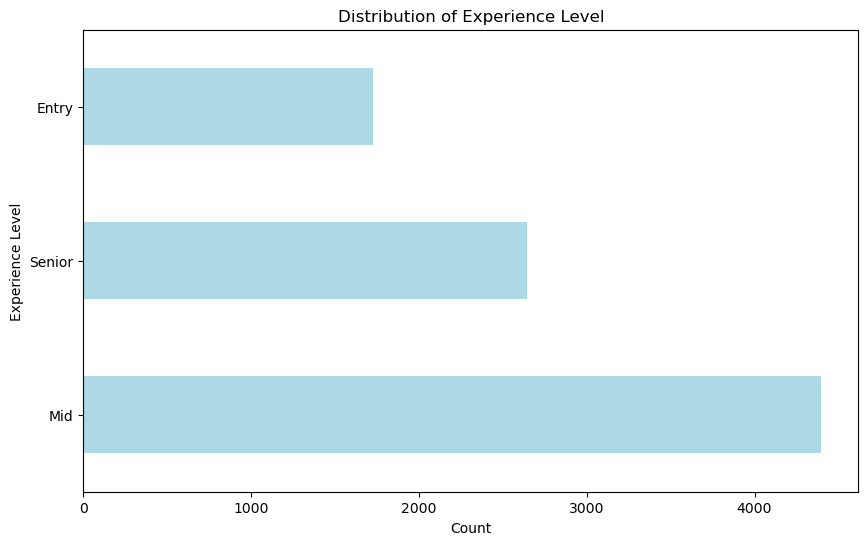

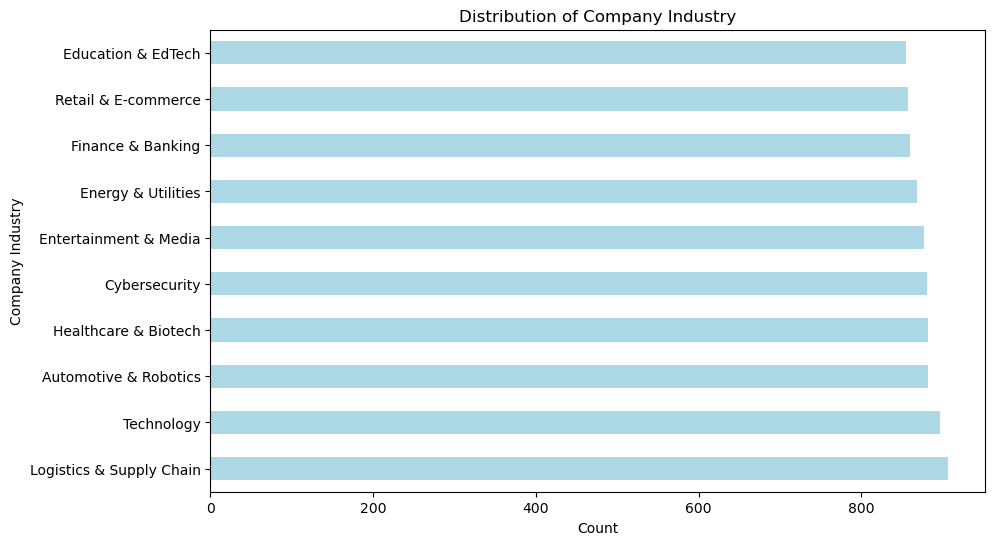

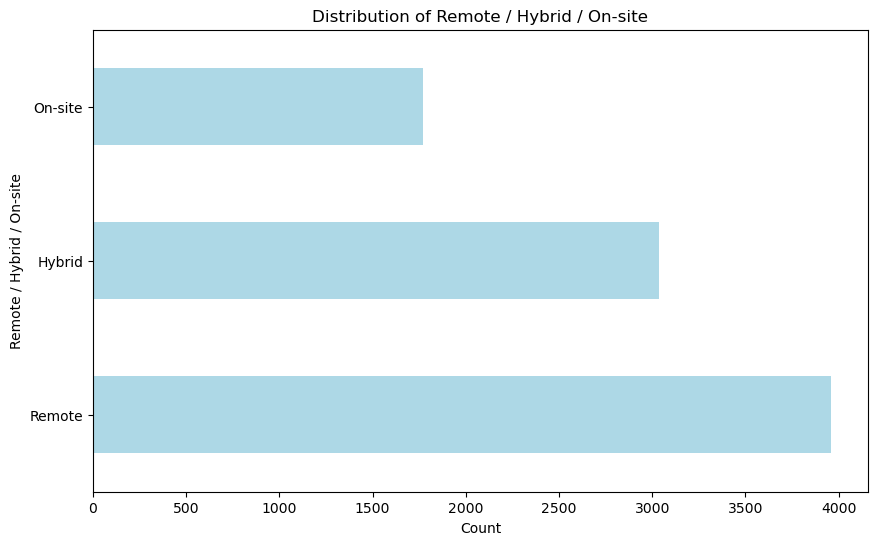

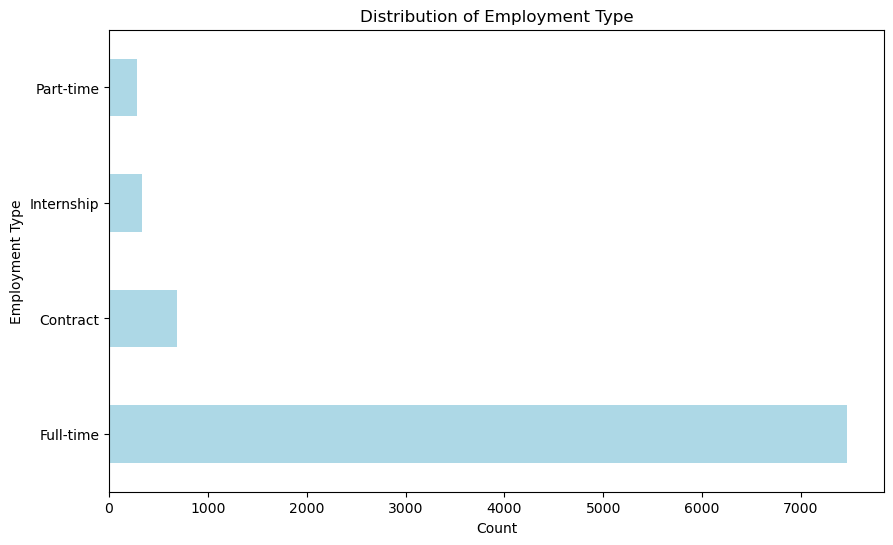

In [8]:
for col in seiw_columns:
    plt.figure(figsize=(10, 6))
    job_postings[col].value_counts().plot(kind='barh', color='lightblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.show()

In [9]:
# Let's show the value counts for AI Specialization, Experience Level, Company Industry, and Remote / Hybrid / On-site
print("AI Specialization Value Counts:\n", job_postings['AI Specialization'].value_counts())
print("\nExperience Level Value Counts:\n", job_postings['Experience Level'].value_counts())
print("\nCompany Industry Value Counts:\n", job_postings['Company Industry'].value_counts())
print("\nRemote / Hybrid / On-site Value Counts:\n", job_postings['Remote / Hybrid / On-site'].value_counts())
print("\nEmployment Type Value Counts:\n", job_postings['Employment Type'].value_counts())

AI Specialization Value Counts:
 AI Specialization
Machine Learning    3245
MLOps               1389
Generative AI       1318
NLP                  961
Computer Vision      945
Deep Learning        485
Data Science         423
Name: count, dtype: int64

Experience Level Value Counts:
 Experience Level
Mid       4399
Senior    2641
Entry     1726
Name: count, dtype: int64

Company Industry Value Counts:
 Company Industry
Logistics & Supply Chain    907
Technology                  897
Automotive & Robotics       882
Healthcare & Biotech        882
Cybersecurity               881
Entertainment & Media       877
Energy & Utilities          868
Finance & Banking           860
Retail & E-commerce         857
Education & EdTech          855
Name: count, dtype: int64

Remote / Hybrid / On-site Value Counts:
 Remote / Hybrid / On-site
Remote     3959
Hybrid     3035
On-site    1772
Name: count, dtype: int64

Employment Type Value Counts:
 Employment Type
Full-time     7465
Contract       684
Int

- For Specializations
    - Machine Learning, MLOps, and Generative AI all have over 1000 postings, the former being by far the most popular specialization
    - Natural Language Processing and Computer Vision are closer to 1000 postings
    - Deep Learning & Data Science are under 500 postings but are still asked for
- For Experience Level
    - Mid level experience (Starting around 5-10 years of experience and ending at around 25-35 years) is by far the most popular
    - There's less entry level postings than senior postings
- For Industry
    - While Logistics & Supply Chain is the most popular company industry with the job postings, there's not much difference here. 
    - Industries seem to be spread somewhat evenly
- For Work Arrangements
    - Remote and Hybrid jobs are more popular than on-site, the former having over twice as many job postings as on-site.
- For Employment Type
    - Full-time Positions are by far the most popular
    - Contract positions seem to be the 2nd most popular, having twice as many positions over part-time work
    - Internships, traditionally entry-level positions, are not the least popular employment type

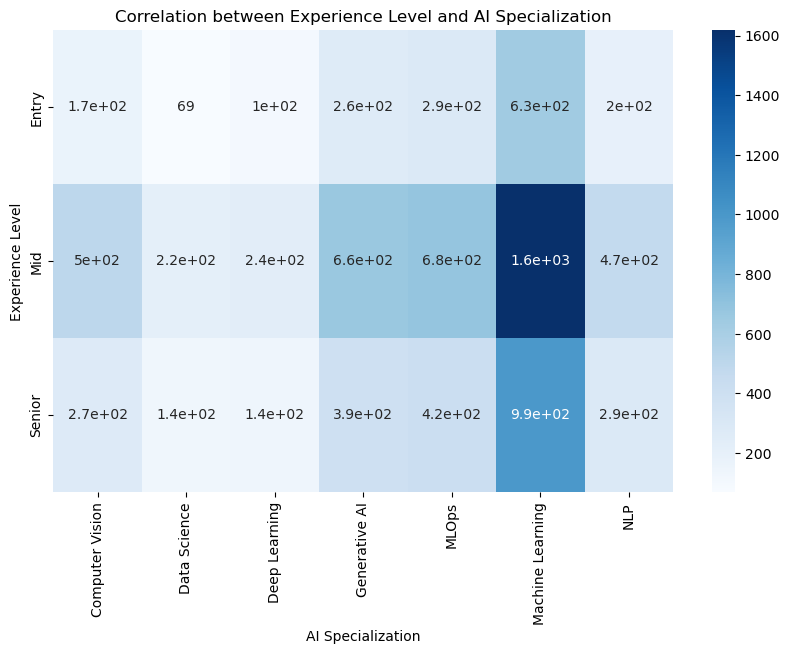

In [10]:
# Let's make a heat map between experience level and AI specialization to see if there are any correlations between the two variables.
experience_specialization_crosstab = pd.crosstab(job_postings['Experience Level'], job_postings['AI Specialization'])

plt.figure(figsize=(10, 6))
sns.heatmap(experience_specialization_crosstab, annot=True, cmap='Blues')
plt.title('Correlation between Experience Level and AI Specialization')
plt.xlabel('AI Specialization')
plt.ylabel('Experience Level')
plt.show()

- So Machine Learning, while having the most postings, requests more people with at least 5 years of experience, supposedly. 
- Overall, more roles ask for people who have medium experience level.
- The spread between Entry Level and Senior level positions across Specializations isn't that different, Machine Learning itself being more popular.

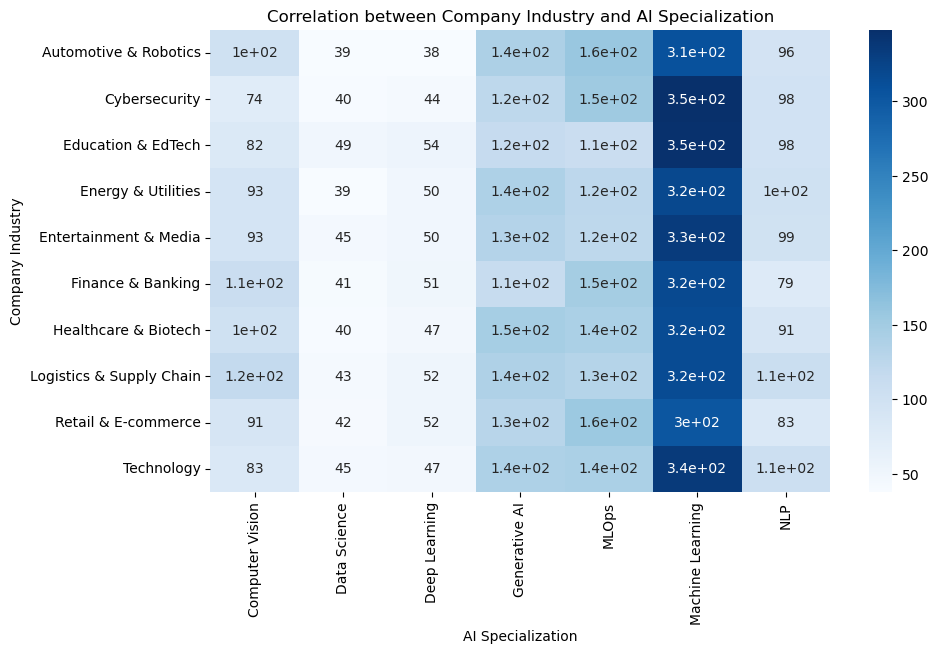

In [11]:
# Let's plot a heat map between Industries and AI Specialization to see if there are any correlations between the two variables.
industry_specialization_crosstab = pd.crosstab(job_postings['Company Industry'], job_postings['AI Specialization'])

plt.figure(figsize=(10, 6))
sns.heatmap(industry_specialization_crosstab, annot=True, cmap='Blues')
plt.title('Correlation between Company Industry and AI Specialization')
plt.xlabel('AI Specialization')
plt.ylabel('Company Industry')
plt.show()

I don't notice anything of note when analyzing specializations over industries. The spread seems to be equal across industries.

## Tackling Question 2 ##

How does compensation differ across AI specializations, experience levels, and work arrangements?

Some hypotheses I have going into this:
- More experienced AI roles have higher salaries.
- Compensation varies significantly between AI specializations.
- Work arrangement is associated with differences in compensation.

In [12]:
# Let's see the salary distribution again 
salaries = job_postings['Salary Range'].dropna()
salaries

0       $140,000 - $180,000
1       $140,000 - $180,000
2       $140,000 - $180,000
3       $140,000 - $180,000
4       $140,000 - $180,000
               ...         
8761      $191000 - $263000
8762      $125000 - $162000
8763    $139,704 - $166,248
8764    $198,379 - $230,511
8765      $138000 - $163000
Name: Salary Range, Length: 8766, dtype: object

In [13]:
# Let's separate the salary range into minimum and maximum salary columns for better analysis.
job_postings[['Min Salary', 'Max Salary']] = job_postings['Salary Range'].str.split('-', expand=True)
# For each first character of both min and max salary, we will remove the dollar sign
job_postings['Min Salary'] = job_postings['Min Salary'].str.replace('$', '')
job_postings['Max Salary'] = job_postings['Max Salary'].str.replace('$', '')
# In both salary lists, we will remove any commas and convert the values to float
job_postings['Min Salary'] = job_postings['Min Salary'].str.replace(',', '').astype(float)
job_postings['Max Salary'] = job_postings['Max Salary'].str.replace(',', '').astype(float)
job_postings[['Min Salary', 'Max Salary']].head(3)

,Min Salary,Max Salary
0,140000.0,180000.0
1,140000.0,180000.0
2,140000.0,180000.0


In [14]:
# We can also add a 'Median Salary' column to the dataset by taking the average of the minimum and maximum salary for each job posting.
job_postings['Median Salary'] = (job_postings['Min Salary'] + job_postings['Max Salary']) / 2

In [15]:
# Let's see the lowest and highest salaries in the dataset
min_low_salary = job_postings['Min Salary'].min()
min_high_salary = job_postings['Min Salary'].max()
max_low_salary = job_postings['Max Salary'].min()
max_high_salary = job_postings['Max Salary'].max()
print(f"The lowest salary offered in the dataset is: ${min_low_salary} - ${max_low_salary}")
print(f"The highest salary offered in the dataset is: ${min_high_salary} - ${max_high_salary}")

The lowest salary offered in the dataset is: $80000.0 - $90000.0
The highest salary offered in the dataset is: $231908.0 - $305000.0


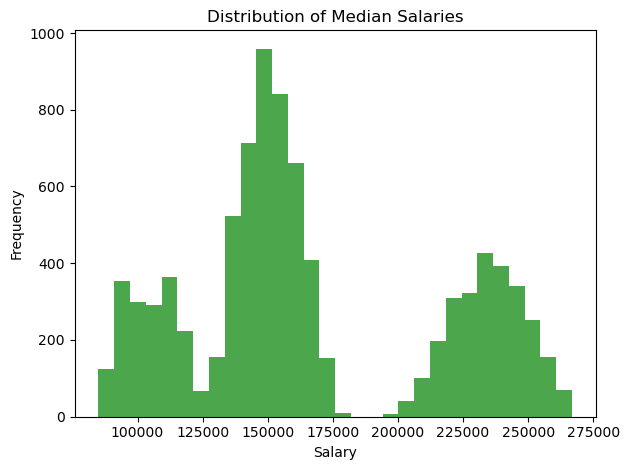

In [16]:
# We can also visualize the distribution of minimum and maximum salaries using histograms
# plt.figure(figsize=(12, 6))
# plt.subplot(1, 3, 1)
# plt.hist(job_postings['Min Salary'], bins=30, color='blue', alpha=0.7)
# plt.title('Distribution of Minimum Salaries')
# plt.xlabel('Salary')
# plt.ylabel('Frequency')

# plt.subplot(1, 3, 2)
# plt.hist(job_postings['Max Salary'], bins=30, color='red', alpha=0.7)
# plt.title('Distribution of Maximum Salaries')
# plt.xlabel('Salary')
# plt.ylabel('Frequency')

# plt.subplot(1, 3, 3)
plt.hist(job_postings['Median Salary'], bins=30, color='green', alpha=0.7) 
plt.title('Distribution of Median Salaries')
plt.xlabel('Salary')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

The median salary distribution shows that most job postings offer salaries in the range of $100,000 to $150,000. There are also some outliers with very high salaries, which may be due to executive-level positions or specialized roles in AI.

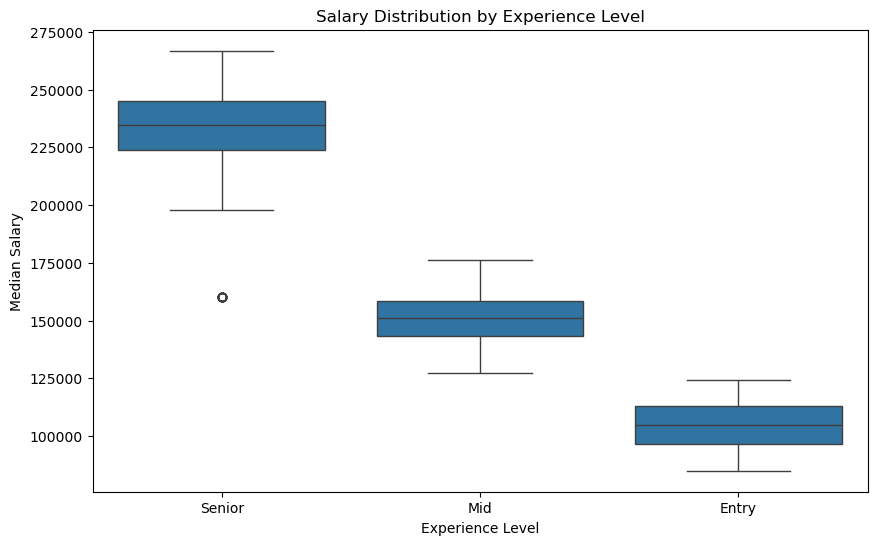

In [17]:
# Let's tackle salary x experience level. We can use a box plot to visualize the distribution of salaries across different experience levels.
plt.figure(figsize=(10, 6))
sns.boxplot(x='Experience Level', y='Median Salary', data=job_postings)
plt.title('Salary Distribution by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Median Salary')
plt.show()

When it comes to experience level, salary distribution is as expected, more experienced roles have higher salary distributions.

We'll pursue Specilization and salary next.

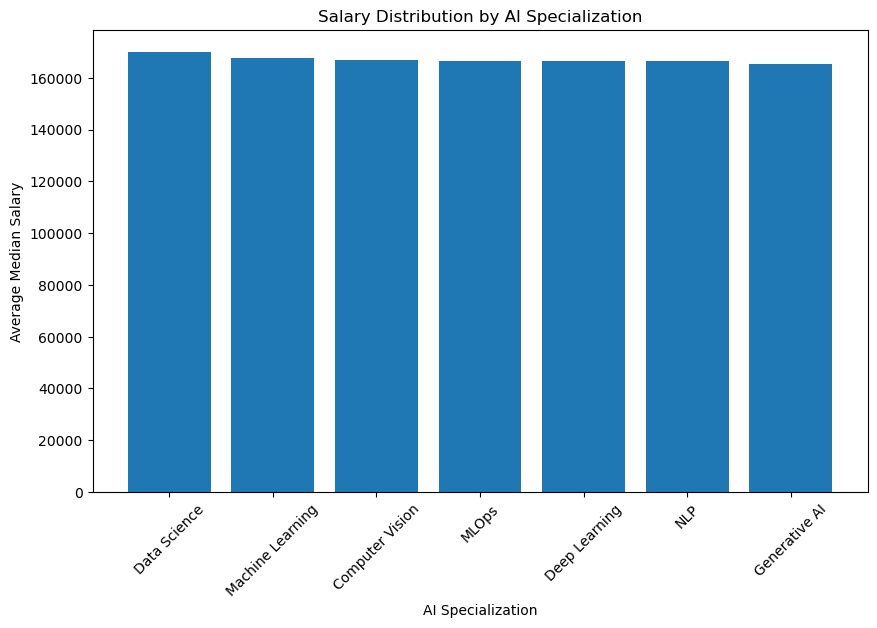

In [18]:
# Let's explore the relationship between salary and AI specialization. We can use a stacked box plot to visualize the distribution of salaries across different AI specializations.
by_specialization = job_postings.groupby('AI Specialization')['Median Salary'].mean().sort_values(ascending=False)
# by_specialization = job_postings.groupby('AI Specialization')['Median Salary'].median().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
plt.bar(by_specialization.index, by_specialization.values)
plt.xlabel('AI Specialization')
plt.ylabel('Average Median Salary')
plt.title('Salary Distribution by AI Specialization')
plt.xticks(rotation=45)
plt.show()



From what we see, AI Specialization doesn't change salary distribution all that much, so that relationship isn't worth pursuing.

Time to explore work arrangement and compensation.

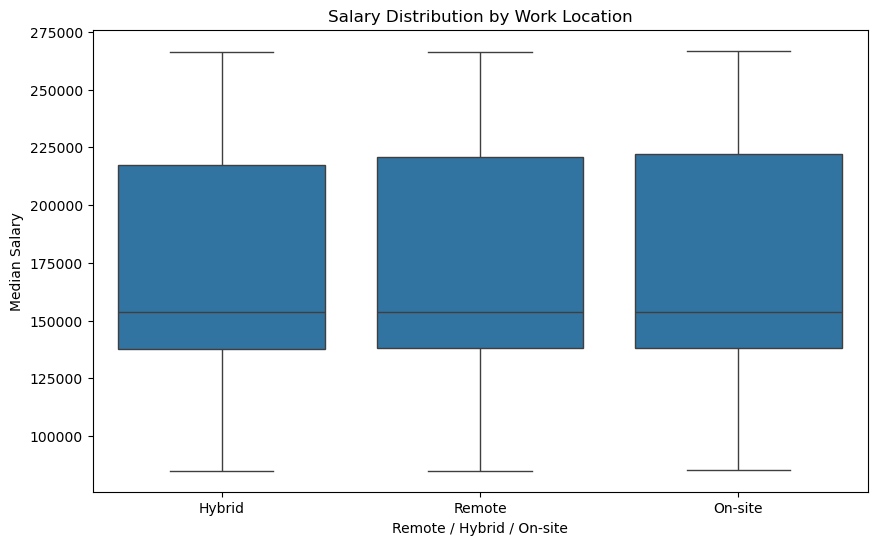

In [19]:
# Let's explore the relationship between salary and work location. We can use a box plot to visualize the distribution of salaries across different work locations.
plt.figure(figsize=(10, 6))
sns.boxplot(x='Remote / Hybrid / On-site', y='Median Salary', data=job_postings)
plt.title('Salary Distribution by Work Location')
plt.show()

## Tackling Question 3 ##

To what extent do job titles correspond to the underlying characteristics of AI jobs?

A hypotheses I have before doing this:
- Similar job titles connect to the characteristics of AI jobs

In [20]:
job_posting_titles = job_postings['Job Title'].unique()
job_posting_titles.sort()
job_posting_titles

array(['AI / ML Engineer', 'AI Agent & Automation Developer',
       'AI Agentic Engineer - Multiple USA locations', 'AI Engineer',
       'AI Engineer II', 'AI Ethics Consultant',
       'AI Platform Engineer - Autonomous Agents', 'AI Product Manager',
       'AI Research Scientist', 'AI Solution Architect',
       'AI Solutions Architect', 'AI Systems Engineer', 'AI/ML Engineer',
       'AI/ML Engineer, Deployed',
       'Applied AI Engineer, Global Public Sector',
       'Artificial (AI) Engineer', 'Artificial Intelligence Engineer',
       'Computer Vision Engineer', 'Computer Vision Researcher',
       'Data Engineer', 'Data Scientist', 'Deep Learning Specialist',
       'Gen AI Engineer', 'Generative AI Architect',
       'LLM Software Developer', 'ML Infrastructure Engineer',
       'ML Platform Developer', 'MLOps Engineer',
       'Machine Learning  Engineer', 'Machine Learning Engineer',
       'Machine Learning Engineer, Global Public Sector', 'NLP Engineer',
       'NLP Rese

This is a lot of titles. We'll start by showing the ones with multiple job postings

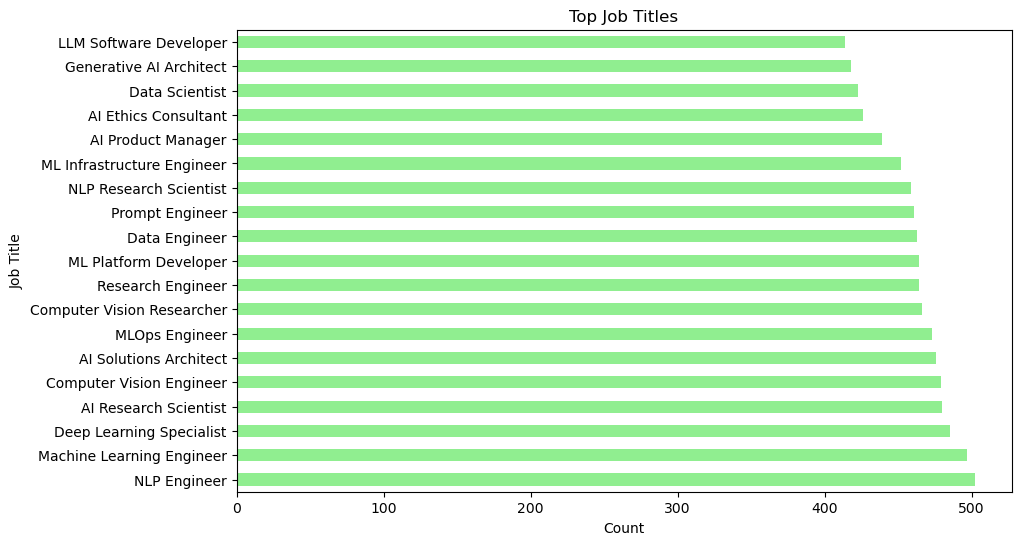

In [21]:
# Plotting the job posting counts by title that have more than 100 postings and then putting those values into a horizontal bar chart, then putting the job posting titles in their own list
job_postings['Job Title'].value_counts()[job_postings['Job Title'].value_counts() > 100].plot(kind='barh', figsize=(10, 6), color='lightgreen')
plt.title('Top Job Titles')
plt.xlabel('Count')
plt.ylabel('Job Title')
plt.show()
popular_job_titles = job_postings['Job Title'].value_counts()[job_postings['Job Title'].value_counts() > 100].index.tolist()

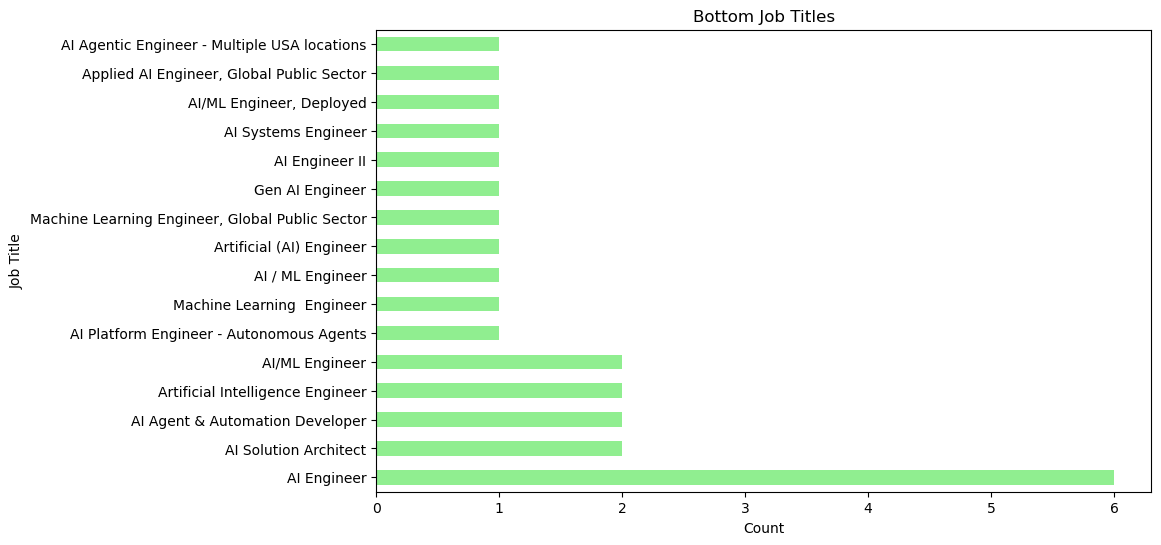

In [22]:
# Plotting the job posting counts by title that have less than 100 postings, and putting those values into a horizontal bar chart, then putting the job posting titles in their own list
job_postings['Job Title'].value_counts()[job_postings['Job Title'].value_counts() < 100].plot(kind='barh', figsize=(10, 6), color='lightgreen')
plt.title('Bottom Job Titles')
plt.xlabel('Count')
plt.ylabel('Job Title')
plt.show()
less_popular_job_titles = job_postings['Job Title'].value_counts()[job_postings['Job Title'].value_counts() < 100].index.tolist()

In [23]:
print("Popular Job Titles:", popular_job_titles)
print("Less Popular Job Titles:", less_popular_job_titles)

Popular Job Titles: ['NLP Engineer', 'Machine Learning Engineer', 'Deep Learning Specialist', 'AI Research Scientist', 'Computer Vision Engineer', 'AI Solutions Architect', 'MLOps Engineer', 'Computer Vision Researcher', 'Research Engineer', 'ML Platform Developer', 'Data Engineer', 'Prompt Engineer', 'NLP Research Scientist', 'ML Infrastructure Engineer', 'AI Product Manager', 'AI Ethics Consultant', 'Data Scientist', 'Generative AI Architect', 'LLM Software Developer']
Less Popular Job Titles: ['AI Engineer', 'AI Solution Architect', 'AI Agent & Automation Developer', 'Artificial Intelligence Engineer', 'AI/ML Engineer', 'AI Platform Engineer - Autonomous Agents', 'Machine Learning  Engineer', 'AI / ML Engineer', 'Artificial (AI) Engineer', 'Machine Learning Engineer, Global Public Sector', 'Gen AI Engineer', 'AI Engineer II', 'AI Systems Engineer', 'AI/ML Engineer, Deployed', 'Applied AI Engineer, Global Public Sector', 'AI Agentic Engineer - Multiple USA locations']


So we can see which job titles have more postings than others. I chose 100 as a starting point to see what would happen, but there's a drastic range differeence in the amount of postings for these titles.
However, specific titles don't mean unpopular or unwanted.

Now we can begin tackling the question.

In [24]:
# The postings with the popular job titles 
more_popular_titles_postings = job_postings[job_postings['Job Title'].isin(popular_job_titles)]
less_popular_titles_postings = job_postings[job_postings['Job Title'].isin(less_popular_job_titles)]
less_popular_titles_postings.head(6)


,Job Title,Company Name,Company Industry,Company Size,Job Location,Remote / Hybrid / On-site,Country,Salary Range,Experience Level,Employment Type,...,Job Description,Posting Date,Benefits Offered,Company Rating,Number of Applicants,Job URL,Data Collection Timestamp,Min Salary,Max Salary,Median Salary
0,AI Agentic Engineer - Multiple USA locations,ClifyX,Technology,"1,001-5,000 employees","Bentonville, AR",Hybrid,United States,"$140,000 - $180,000",Senior,Full-time,...,We are seeking a senior AI Engineer to lead ge...,2026-06-22,"Health insurance, 401(k), Unlimited PTO",4.2,42,https://www.linkedin.com/jobs/view/ai-agentic-...,2026-06-22T11:41:12.537989,140000.0,180000.0,160000.0
1,AI Engineer,Casumo,Technology,"1,001-5,000 employees","Swieqi, Malta",Hybrid,United States,"$140,000 - $180,000",Senior,Full-time,...,We are seeking a senior AI Engineer to lead ge...,2026-06-22,"Health insurance, 401(k), Unlimited PTO",4.2,42,https://mt.linkedin.com/jobs/view/ai-engineer-...,2026-06-22T11:41:12.540233,140000.0,180000.0,160000.0
2,"Applied AI Engineer, Global Public Sector",Scale AI,Technology,"1,001-5,000 employees","Doha, Qatar",Hybrid,United States,"$140,000 - $180,000",Senior,Full-time,...,We are seeking a senior AI Engineer to lead ge...,2026-06-22,"Health insurance, 401(k), Unlimited PTO",4.2,42,https://qa.linkedin.com/jobs/view/applied-ai-e...,2026-06-22T11:41:12.545900,140000.0,180000.0,160000.0
3,"Machine Learning Engineer, Global Public Sector",Scale AI,Technology,"1,001-5,000 employees","Doha, Qatar",Hybrid,United States,"$140,000 - $180,000",Senior,Full-time,...,We are seeking a senior AI Engineer to lead ge...,2026-06-22,"Health insurance, 401(k), Unlimited PTO",4.2,42,https://qa.linkedin.com/jobs/view/machine-lear...,2026-06-22T11:41:12.547144,140000.0,180000.0,160000.0
4,AI Agent & Automation Developer,Cherry Bekaert,Technology,"1,001-5,000 employees","Augusta, GA",Hybrid,United States,"$140,000 - $180,000",Senior,Full-time,...,We are seeking a senior AI Engineer to lead ge...,2026-06-22,"Health insurance, 401(k), Unlimited PTO",4.2,42,https://www.linkedin.com/jobs/view/ai-agent-au...,2026-06-22T11:41:12.548409,140000.0,180000.0,160000.0
5,Artificial Intelligence Engineer,Fivecast,Technology,"1,001-5,000 employees","Adelaide, South Australia, Australia",Hybrid,United States,"$140,000 - $180,000",Senior,Full-time,...,We are seeking a senior AI Engineer to lead ge...,2026-06-22,"Health insurance, 401(k), Unlimited PTO",4.2,42,https://au.linkedin.com/jobs/view/artificial-i...,2026-06-22T11:41:12.549894,140000.0,180000.0,160000.0


In [25]:
# With the different job titles, I need to see how they differ in terms of salary, experience level, skills, and specialization

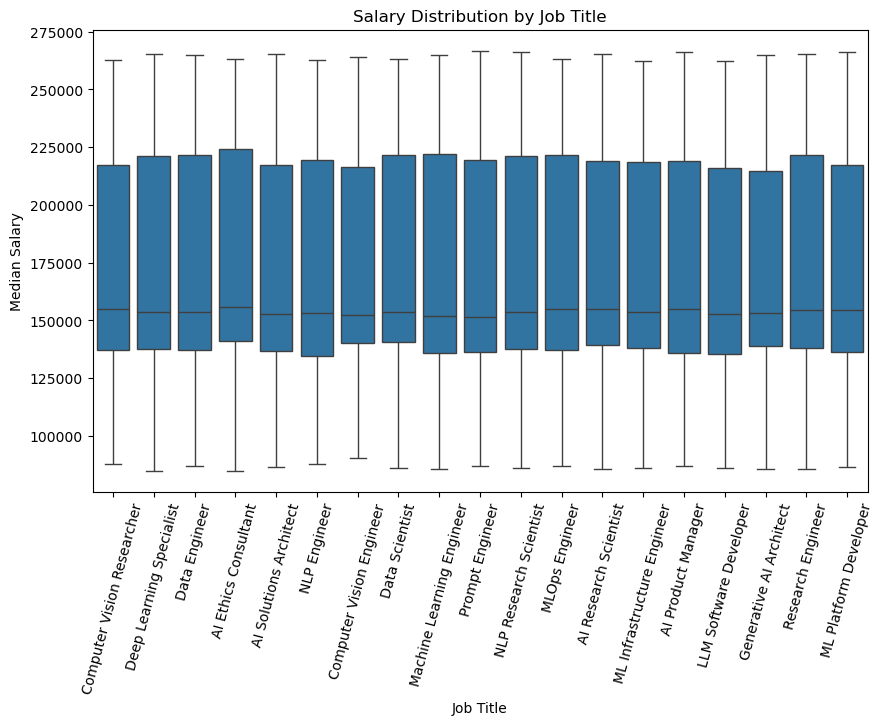

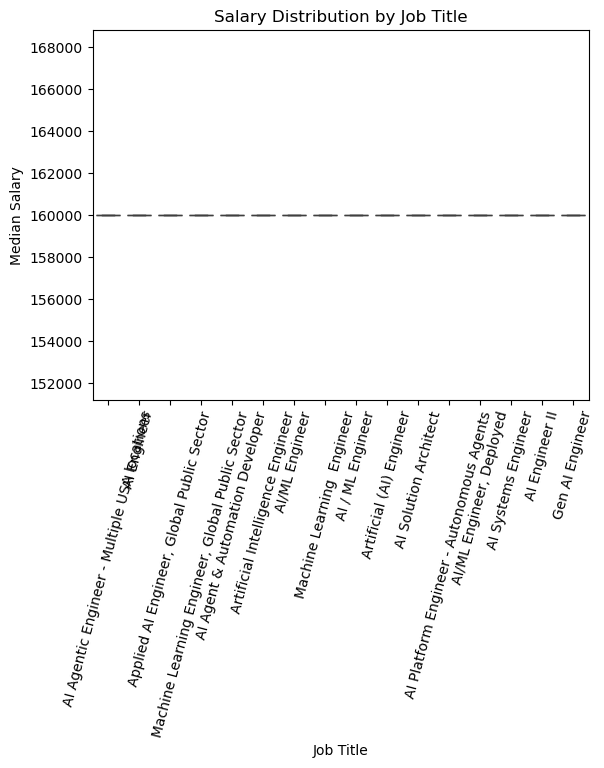

In [26]:
# How do the titles differ in salary? Let's use a box plot to visualize the distribution of salaries across different job titles.
plt.figure(figsize=(10, 6))
sns.boxplot(data=more_popular_titles_postings, x='Job Title', y='Median Salary')
plt.xticks(rotation=75)
plt.title('Salary Distribution by Job Title')
plt.xlabel('Job Title')
plt.ylabel('Median Salary')
plt.show()
# Clear the plot and prepare the next one
plt.clf()
sns.boxplot(data=less_popular_titles_postings, x='Job Title', y='Median Salary')
plt.xticks(rotation=75)
plt.title('Salary Distribution by Job Title')
plt.xlabel('Job Title')
plt.ylabel('Median Salary')
plt.show()

Job title doesn't seem to make any difference for salary

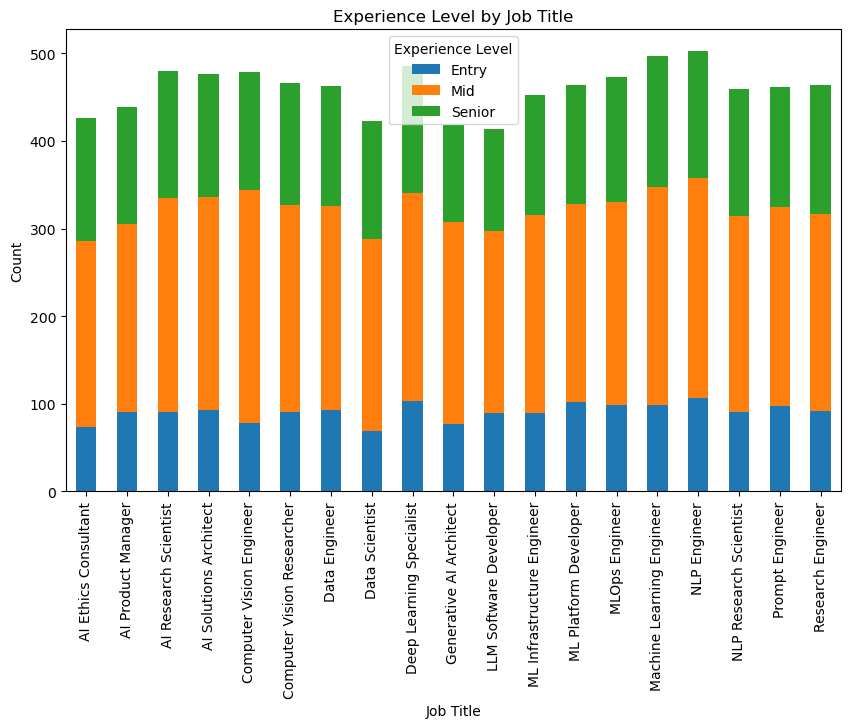

<Figure size 640x480 with 0 Axes>

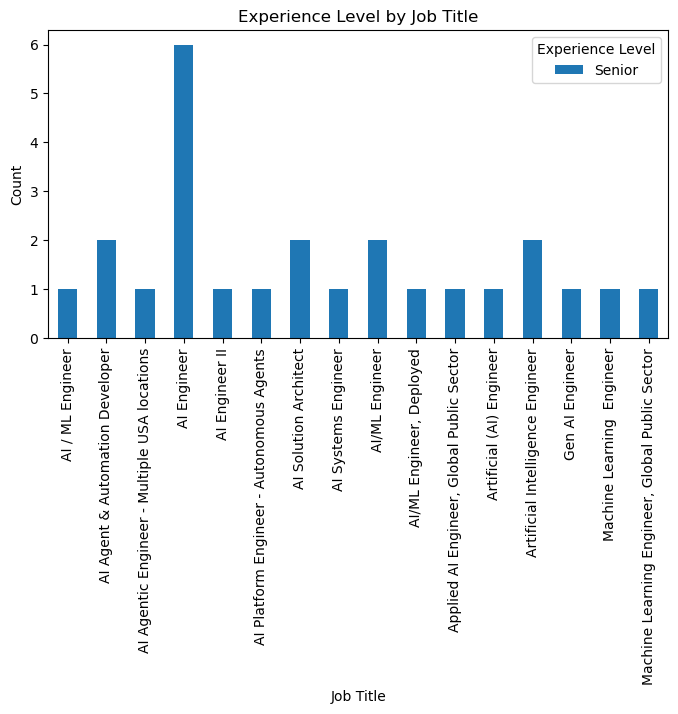

In [27]:
# Let's explore the relationship between Job Titles and Experience Level. We can use a stacked bar chart to visualize the distribution of experience levels across different job titles.
experience_title_crosstab = pd.crosstab(more_popular_titles_postings['Job Title'], more_popular_titles_postings['Experience Level'])
experience_title_crosstab.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Experience Level by Job Title')
plt.xlabel('Job Title')
plt.ylabel('Count')
plt.show()
plt.clf()
experience_title_crosstab = pd.crosstab(less_popular_titles_postings['Job Title'], less_popular_titles_postings['Experience Level'])
experience_title_crosstab.plot(kind='bar', stacked=True, figsize=(8, 4))
plt.title('Experience Level by Job Title')
plt.xlabel('Job Title')
plt.ylabel('Count')
plt.show()

So for the less popular titles, there's more people looking for senior-level experience. 
But for the more popular job titles, there seems to be more interest in mid-level experience overall.
There doesn't seem to be too much variation, but there does seem to be some impact  between job titles and experience level.

In [28]:
print(type(more_popular_titles_postings["Required Skills"]))

<class 'pandas.core.series.Series'>


From here, it leads closer into checking skills, which leads into question 4.

# Tackling Question 4 #

What technical skills  are associated with different AI specializaitons and postings?

Here's a couple hypotheses I have going into this:
- Data manipulation skills are the most common ones.

In [29]:
# This function will take in a dataframe. We'll have a dictionary to store the skills. For every row, it'll get the string from the 'Required Skills' column, split it by commas, and get a list of skills.
# Then, it'll store the skill in the dictionary as the key and the count of the skill as the value. Finally, it'll return the dictionary of skills and their counts.
def count_skills(df):
    skill_counts = {}
    for skills in df['Required Skills'].dropna():
        skill_list = [skill.strip() for skill in skills.split(',')]
        for skill in skill_list:
            if skill in skill_counts:
                skill_counts[skill] += 1
            else:
                skill_counts[skill] = 1
    return skill_counts

In [30]:
# Given a dictionary of skills and their counts, this removes any skills that have a count of less than 100. This is to remove any skills that are not common enough to be useful for our analysis.
def filter_skills(skill_counts, min_count=50):
    filtered_skills = {skill: count for skill, count in skill_counts.items() if count >= min_count}
    return filtered_skills

In [31]:
# Now we'll evaluate the skills required for the different job titles. We can use a stacked bar chart to visualize the distribution of skills across different job titles.
# First, we'll call a function to count the skills in the more popular job titles postings and then create a crosstab of the skills and job titles. Finally, we'll plot the crosstab as a stacked bar chart.
skill_counts = count_skills(more_popular_titles_postings)
skill_counts = filter_skills(skill_counts, min_count=5)
# Next we need to convert skills_count into something that can be used to create a crosstab. We can create a new dataframe with the skills as columns and the job titles as rows. The values in the dataframe will be the counts of each skill for each job title.
skills_df = pd.DataFrame(columns=skill_counts.keys())
skills_df['Job Title'] = more_popular_titles_postings['Job Title'].unique()
for index, row in skills_df.iterrows():
    job_title = row['Job Title']
    job_postings_for_title = more_popular_titles_postings[more_popular_titles_postings['Job Title'] == job_title]
    skill_counts_for_title = count_skills(job_postings_for_title)
    for skill in skill_counts.keys():
        skills_df.at[index, skill] = skill_counts_for_title.get(skill, 0)
skills_df.fillna(0, inplace=True)
skills_df.set_index('Job Title', inplace=True)

In [37]:
skills_df.head(6)

,Pandas,OpenCV,OCR,Object Detection,Image Segmentation,PyTorch,YOLO,A/B Testing,Feature Engineering,ResNet,...,Stable Diffusion,Prompt Engineering,LlamaIndex,CI/CD,Docker,Kubeflow,MLflow,Git,Terraform,AWS SageMaker
Job Title,,,,,,,,,,,,,,,,,,,,,
Computer Vision Researcher,34,466,466,466,466,466,466,19,16,466,...,23,12,15,20,20,12,25,19,17,16
Deep Learning Specialist,41,17,8,21,25,485,16,24,16,12,...,18,16,21,19,23,10,15,22,16,17
Data Engineer,463,19,11,32,25,27,14,19,463,16,...,26,24,7,23,23,13,15,11,11,23
AI Ethics Consultant,426,17,11,18,6,31,19,19,426,16,...,16,11,13,20,18,14,17,12,21,15
AI Solutions Architect,476,15,15,19,20,37,22,15,476,10,...,16,23,18,17,13,18,16,20,16,15
NLP Engineer,32,15,15,11,21,33,18,23,10,14,...,17,15,24,19,24,26,18,13,14,19


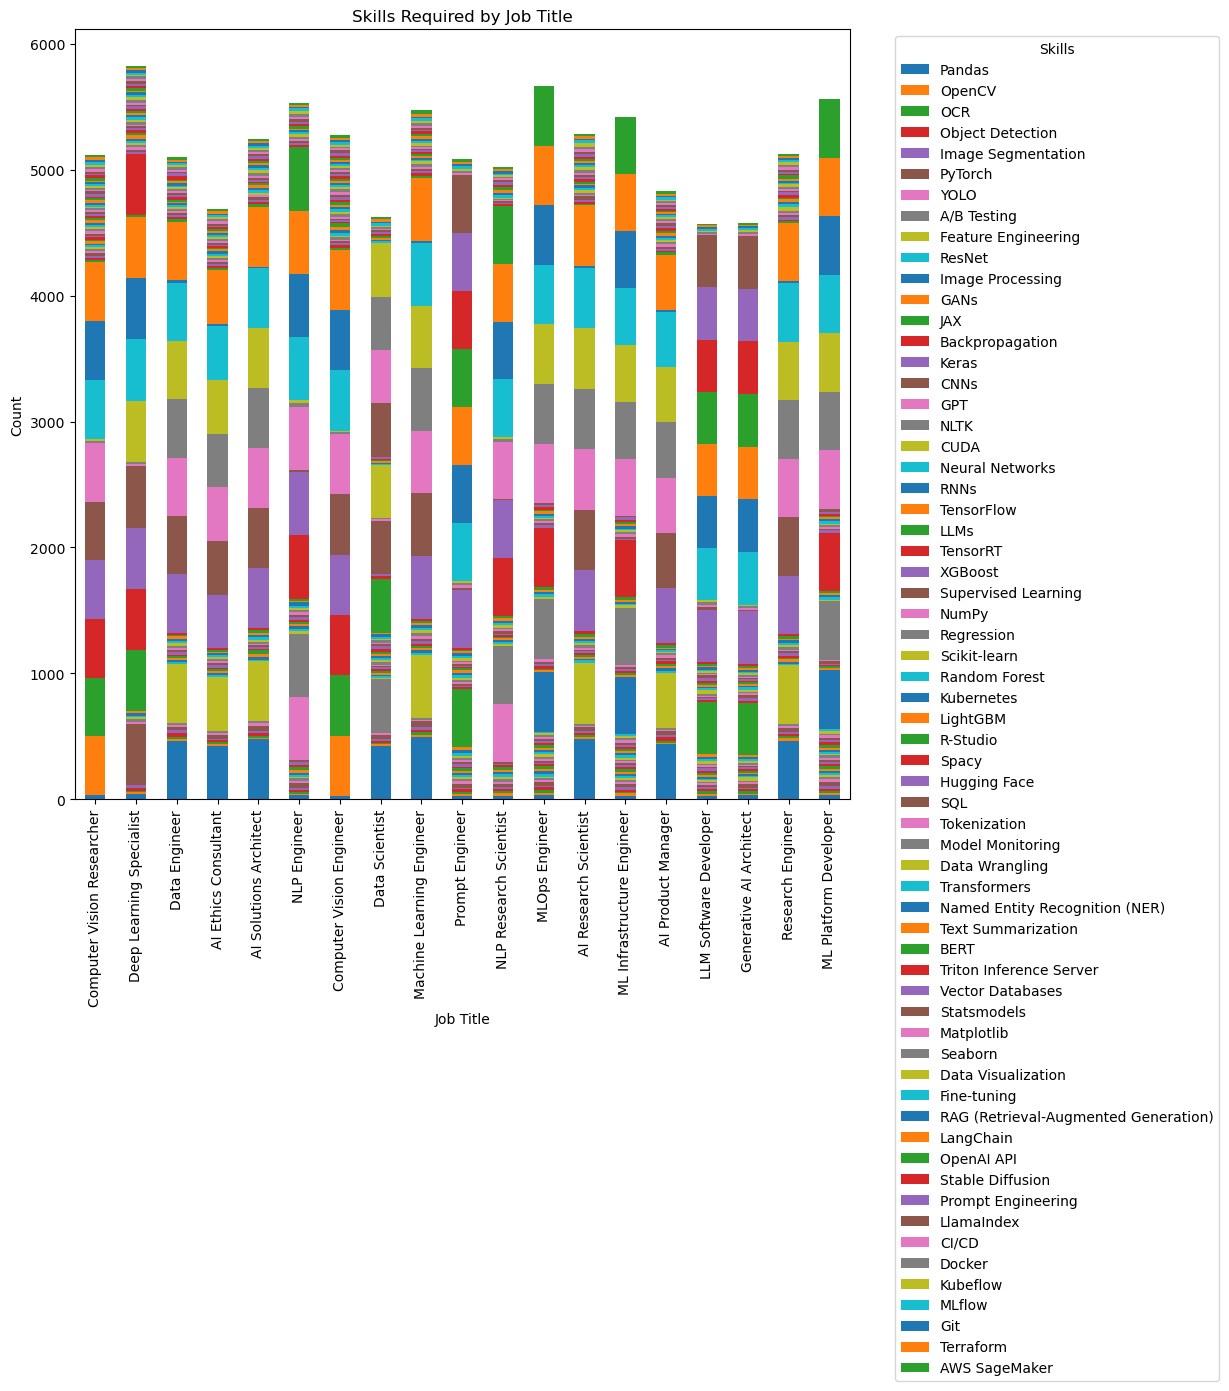

In [32]:
# Now that we have the skills df, we can create a crosstab of the skills and job titles (with skills using skills_df). Finally, we'll plot the crosstab as a stacked bar chart.
skills_title_crosstab = skills_df
skills_title_crosstab = skills_title_crosstab[skills_title_crosstab.sum(axis=1) > 0]  # Filter out job titles with no skills

skills_title_crosstab.plot(kind='bar', stacked=True, figsize=(10, 10))
plt.legend(title='Skills', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Skills Required by Job Title')
plt.xlabel('Job Title')
plt.ylabel('Count')
plt.show()


# skills_title_crosstab = pd.crosstab(more_popular_titles_postings['Job Title'], more_popular_titles_postings['Skills'])
# skills_title_crosstab.plot(kind='bar', stacked=True, figsize=(10, 6))
# plt.title('Skills Required by Job Title')   
# plt.xlabel('Job Title')
# plt.ylabel('Count')
# plt.show()

The image is hard to read, but skill requirements vary noticeably by job title. Here's some groupings I've noticed from this
- Computer Vision Researcher / Computer Vision Engineer show heavier requirements around vision-oriented skills such as OpenCV, image processing, object detection, image segmentation, YOLO, ResNet, CNNs, and PyTorch.
- NLP Engineer / NLP Research Scientist lean more toward NLTK, tokenization, Transformers, BERT, named entity recognition, text summarization, spaCy, and Hugging Face.
- LLM Software Developer / Generative AI Architect / Prompt Engineer appear more associated with the newer generative-AI stack: LLMs, GPT, Transformers, Hugging Face, vector databases, LangChain, OpenAI API, RAG, prompt engineering, and LlamaIndex.
- Data Scientist / Data Engineer appear comparatively oriented toward traditional data/ML tooling such as Pandas, NumPy, Scikit-learn, SQL, data wrangling, data visualization, regression, Random Forest, and related tools.
- ML Infrastructure Engineer / ML Platform Developer / MLOps Engineer have more infrastructure-oriented requirements, including things such as Docker, Kubernetes, MLflow, CI/CD, Git, Terraform, Kubeflow, and AWS SageMaker.
- Machine Learning Engineer / AI Research Scientist / Research Engineer look broader. Rather than being dominated by one narrow family, they draw from multiple ML, deep-learning, and engineering skills.

Overall, I'd say similar job titles appear across multiple skill profiles. 

I think we can make some of those skill profiles from this as well. Let's take a quick break from analyzing the skills involved to make groupings of said skills. This also leads to tackling the next question.

In [33]:
# This will calculate the division between postings for titles requiring a skill and the total positngs for a title, for all skills
def calculate_skill_division(df, skills_df):
    skill_division = {}
    for skill in skills_df.columns:
        total_postings_for_skill = df[df['Required Skills'].str.contains(skill, na=False)].shape[0]
        total_postings_for_title = df.shape[0]
        skill_division[skill] = total_postings_for_skill / total_postings_for_title if total_postings_for_title > 0 else 0
    return skill_division

In [34]:
# Now let's calculate all the percentages
skill_division = calculate_skill_division(more_popular_titles_postings, skills_df)
skill_division_df = pd.DataFrame(list(skill_division.items()), columns=['Skill', 'Percentage'])
skill_division_df.sort_values(by='Percentage', ascending=False, inplace=True)
skill_division_df.reset_index(drop=True, inplace=True)

C:\Users\bruno\AppData\Local\Temp\ipykernel_79952\815063362.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  total_postings_for_skill = df[df['Required Skills'].str.contains(skill, na=False)].shape[0]


In [36]:
# This posts the table to a text file
with open('../data/processed/skill_division.txt', 'w') as f:
    f.write(skill_division_df.to_string(index=False))   

In [116]:
# Print the dataframe percentage by groups.
# Print the percentage of skills over 40
print("Skills with percentage over 40%:")
print(skill_division_df[skill_division_df['Percentage'] > 0.4])
print("Skills with percentage between 30% and 40%")
print(skill_division_df[(skill_division_df['Percentage'] >= 0.3) & (skill_division_df['Percentage'] <= 0.4)])
# I ended up having to split values below 20 to fit stuff better.
print("Skills with percentage between 18% and 20%")
print(skill_division_df[(skill_division_df['Percentage'] >= 0.18) & (skill_division_df['Percentage'] <= 0.25)])
print("Skills with percentage between 15% and 18%")
print(skill_division_df[(skill_division_df['Percentage'] >= 0.15) & (skill_division_df['Percentage'] <= 0.18)])
print("Skills with percentage between 10% and 15%")
print(skill_division_df[(skill_division_df['Percentage'] >= 0.1) & (skill_division_df['Percentage'] <= 0.15)])
print("end==Skills with percentage between 5% and 10%")
print(skill_division_df[(skill_division_df['Percentage'] >= 0.05) & (skill_division_df['Percentage'] <= 0.1)])

Skills with percentage over 40%:
    Skill  Percentage
0  Pandas    0.460359
Skills with percentage between 30% and 40%
                 Skill  Percentage
1             LightGBM    0.395721
2         Scikit-learn    0.395264
3        Random Forest    0.394920
4           Regression    0.394577
5              XGBoost    0.393891
6                NumPy    0.393548
7  Supervised Learning    0.392861
8  Feature Engineering    0.392404
Skills with percentage between 18% and 20%
                      Skill  Percentage
9                   PyTorch    0.221485
10                   MLflow    0.191969
11            AWS SageMaker    0.191740
12                    CI/CD    0.190939
13  Triton Inference Server    0.190482
14                Terraform    0.190024
15                   Docker    0.190024
16               Kubernetes    0.189338
17                 Kubeflow    0.188308
18         Model Monitoring    0.187850
19                      Git    0.186249
20         Stable Diffusion    0.180414
Sk

Pandas is the most prevalent skill, used in over 46% of job postings. 
Using this data, we can put the skills into groups to provide families of skills
- Traditional ML / Data Manipulation (39-46% prevalence) - Ex: 
    - Pandas
    - Scikit-lean
    - Numpy
    - XGBoost
    - Regression
- PyTorch (22% prevalent) - League of it's own
- MLOps / Infrastructure (19% prevalence) - Ex:
    - Docker
    - Kubernetes
    - MLflow
    - CI/CD
    - Kubeflow
- Generative AI / LLM (18% prevalence) - Ex:
    - LLMs
    - LangChain
    - Prompt Engineering
    - Vector DBs
- NLP / Computer Vision (14% prevalence) - Ex:
    - BERT
    - NLTK
    - OpenCV
    - YOLO
    - ResNet
- Deep Learning / Data Analysis (8-9% Prevalence) - Ex:
    - TensorFlow
    - Keras
    - CUDA
    - CNNs
    - SQL
    - Matplotlib

This helps, but to answer the question from above, I think we can move stuff into another dataframe

In [46]:
# We'll get percentages of stuff first
title_counts = more_popular_titles_postings['Job Title'].value_counts()
skills_pct_df = skills_df.div(title_counts, axis=0) * 100

In [47]:
skills_pct_df = skills_df.div(
    more_popular_titles_postings['Job Title'].value_counts(),
    axis=0
) * 100

# skills_pct_df.round(1) This was used to check if the indeces match for percentages of skills for each job title.

In [48]:
skill_matrix = (
    more_popular_titles_postings['Required Skills']
    .str.get_dummies(sep=',')
)
skills_clean = (
    more_popular_titles_postings['Required Skills']
    .fillna('')
    .str.split(',')
    .apply(lambda skills: ','.join(skill.strip() for skill in skills))
)

skill_matrix = skills_clean.str.get_dummies(sep=',')

In [49]:
# Now we use insert the title for the percentages
skill_matrix.insert(
    0,
    'Job Title',
    more_popular_titles_postings['Job Title'].values
)

In [51]:
skills_by_title = (
    skill_matrix
    .groupby('Job Title')
    .mean()
    .mul(100)
) # The mean of binary values is the proportion of when it appears.
skills_by_title.head(2)

,A/B Testing,AWS SageMaker,BERT,Backpropagation,CI/CD,CNNs,CUDA,Data Visualization,Data Wrangling,Docker,...,TensorFlow,TensorRT,Terraform,Text Summarization,Tokenization,Transformers,Triton Inference Server,Vector Databases,XGBoost,YOLO
Job Title,,,,,,,,,,,,,,,,,,,,,
AI Ethics Consultant,4.460094,3.521127,2.582160,2.816901,4.694836,4.694836,4.225352,3.286385,5.164319,4.225352,...,2.816901,3.990610,4.929577,3.521127,3.051643,2.816901,3.286385,2.112676,100.0,4.460094
AI Product Manager,2.733485,4.100228,4.555809,3.872437,4.328018,4.328018,2.277904,4.100228,4.100228,3.189066,...,2.505695,3.416856,4.783599,4.328018,4.328018,3.644647,4.783599,3.872437,100.0,2.505695


Which skills are distinct between jobs?

In [55]:
overall_pct = (
    skill_matrix
    .drop(columns='Job Title')
    .mean()
    .mul(100)
)

skill_difference = skills_by_title.subtract(overall_pct, axis=1)

skill_difference.loc['Computer Vision Engineer'].sort_values(
    ascending=False
).head(10)

OCR                   86.180071
ResNet                86.099989
OpenCV                86.008466
YOLO                  85.928383
Image Processing      85.916943
Image Segmentation    85.894062
GANs                  85.848301
Object Detection      85.688136
PyTorch               77.851504
RNNs                  -3.097991
Name: Computer Vision Engineer, dtype: float64

OCR, ResNet, OpenCV, YOLO, ImageProcessing, Image Segmenttaion, GANs, Object Detection, and PyTorch all appear in different types of roles.

I want to see the Specialization variance for skills now.

In [56]:
# We'll do a similar thing for the skills compared to AI Specialization now
skill_matrix = (
    more_popular_titles_postings['Required Skills']
    .fillna('')
    .str.split(',')
    .apply(lambda skills: ','.join(skill.strip() for skill in skills))
    .str.get_dummies(sep=',')
)

skill_matrix.insert(0, 'AI Specialization', more_popular_titles_postings['AI Specialization'].values)

skill_matrix.insert(0, 'Job Title', more_popular_titles_postings['Job Title'].values)


In [57]:
skills_by_specialization = (
    skill_matrix
    .drop(columns='Job Title')
    .groupby('AI Specialization')
    .mean()
    .mul(100)
)

In [58]:
# Making skill columns again for specializations
skill_columns = skill_matrix.columns.drop(
    ['Job Title', 'AI Specialization']
)

overall_skill_pct = (
    skill_matrix[skill_columns]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

In [60]:
# Calculating specialization differences
specialization_difference = (
    skills_by_specialization
    .subtract(overall_skill_pct, axis=1)
)

,A/B Testing,AWS SageMaker,BERT,Backpropagation,CI/CD,CNNs,CUDA,Data Visualization,Data Wrangling,Docker,...,TensorFlow,TensorRT,Terraform,Text Summarization,Tokenization,Transformers,Triton Inference Server,Vector Databases,XGBoost,YOLO
AI Specialization,,,,,,,,,,,,,,,,,,,,,
Computer Vision,-4.816479,-15.258664,-10.582410,-5.462852,-15.390221,-4.919455,-6.017703,-4.590542,-4.988084,-15.616159,...,-4.567685,-5.623029,-15.404519,-9.681517,-9.578554,-11.094356,-15.450280,-13.582660,-36.743583,85.928383
Data Science,91.797277,-15.155095,-12.077401,-5.564170,-16.020639,-6.364912,-5.434567,91.705754,91.625672,-15.456303,...,-5.808257,-4.019967,-14.037863,-11.394902,-10.819126,-11.562666,-15.738471,-13.927138,-33.242514,-9.343484
Deep Learning,-3.254269,-15.668853,-10.463499,91.362544,-15.176399,91.271022,91.019334,-3.345792,-5.487730,-14.260134,...,90.882050,90.779087,-15.703433,-10.108070,-11.242220,-9.420871,-15.543009,-14.204490,-35.265375,-10.772647
Generative AI,-5.109142,-15.771069,-11.029752,-5.311856,-16.155023,-5.480719,-5.268369,-5.123325,-4.971389,-15.290105,...,-4.245560,-5.817974,-15.754143,-11.138200,-11.421935,-10.914879,-14.639811,82.290356,-35.754128,-10.513999
MLOps,-5.034976,80.825992,-9.648999,-5.253726,80.906075,-5.705220,-5.380954,-5.414476,-5.278576,80.997598,...,-5.446244,-5.333224,80.997598,-10.632069,-10.097141,-9.915479,80.951836,-13.893949,-36.149345,-9.967945


In [62]:
# Getting top distinguishing skills automatically 

top_distinguishing_skills = {}

for specialization in specialization_difference.index:
    top_distinguishing_skills[specialization] = (
        specialization_difference
        .loc[specialization]
        .sort_values(ascending=False)
        .head(5)
    )

for specialization, skills in top_distinguishing_skills.items():
    print(f"\n{specialization}")
    print(skills)


Computer Vision
OCR                 86.180071
ResNet              86.099989
OpenCV              86.008466
YOLO                85.928383
Image Processing    85.916943
Name: Computer Vision, dtype: float64

Data Science
Matplotlib            92.014644
Statsmodels           91.911681
SQL                   91.865919
A/B Testing           91.797277
Data Visualization    91.705754
Name: Data Science, dtype: float64

Deep Learning
Backpropagation    91.362544
CNNs               91.271022
CUDA               91.019334
Neural Networks    90.939252
Keras              90.939252
Name: Deep Learning, dtype: float64

Generative AI
Vector Databases                        82.290356
LangChain                               82.278915
RAG (Retrieval-Augmented Generation)    82.256035
Fine-tuning                             82.244594
OpenAI API                              82.198833
Name: Generative AI, dtype: float64

MLOps
Git                 81.375129
Model Monitoring    81.214964
Kubeflow            81

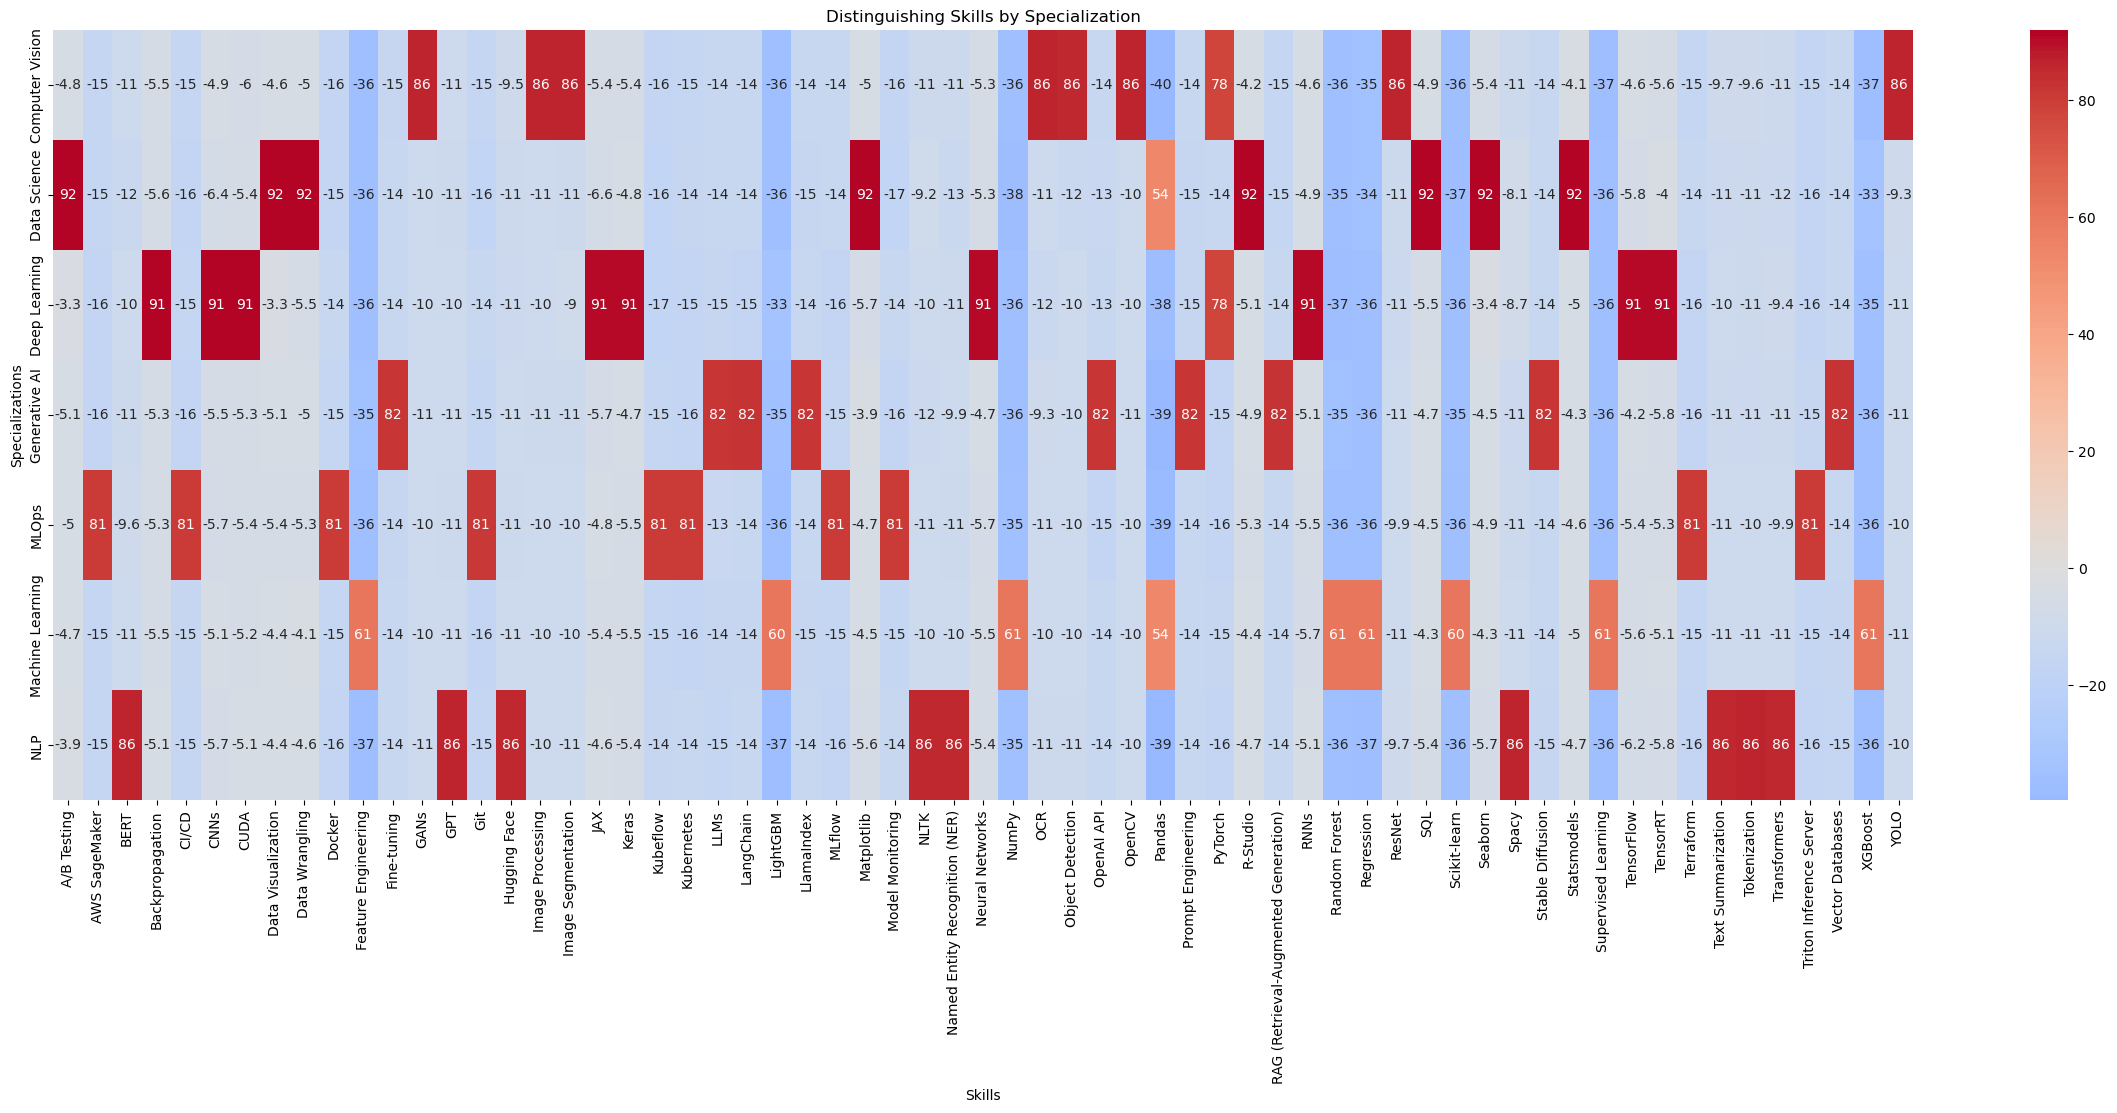

In [73]:
# heatmap between skills and specialization 
plt.figure(figsize=(30,10))
sns.heatmap(specialization_difference, annot=True, cmap='coolwarm', center=0)
plt.title('Distinguishing Skills by Specialization')
plt.xlabel('Skills')
plt.ylabel('Specializations')
plt.show()

Ovearll, some specializations have differences appearing in the heatmap in all kinds of ways. 
So Different AI Specializations exhibit distinct technical skill profiles.

Data Science has strongest differences (~+92% point differences) for:
- A/B Testing
- Data Visualization
- Data Wrangling
- Matplotlib
- R-Studio
- SQL
- Scikit-learn
- Seaborn
- Statsmodels

Also some skills are dispraportionately characteristic of Data Science, so they'll be a lot less useful.

Deep Learning has strongest differences (~+91% point differences) for:
- Backpropagation
- CNNs
- CUDA
- JAX
- Keras
- Neural Networks
- RNNSs
- TensorFlow
- TensorRT

Overall it's a very coherent technical group, neural-network architectures, frameworks, and GPU/Deep-learning technologies

Computer Vision has strongest differences (~ +78 to +86 % point differences) for:
- GANs
- Image Processing
- Image Segmentation
- Object Detection
- OpenCV
- PyTorch
- ResNet
- YOLO

Lots of vision related skills here

Generative AI has strongest differences (~+82 % point differences) for:
- Fine-tuning
- LLMs
- LangChain
- LlamaIndex
- OpenAI API
- Prompt Engineering
- RAG
- Stable Diffusion
- Vector Databases

Generative AI poistings have a very distinctive modern LLM-oriented skill ecosystem comapred with AI Postings overall

MLOps has strongest differences (~+81 % point differences) for:
- AWS SageMaker
- CI/CD
- Docker
- Git
- Kubeflow
- Kubernetes
- MLflow
- Model Monitoring
- Terraform
- Triton Interference Server

MLOps appears to be differentiated not simply by different AI models, but by an emphasis on the infrastructure and operational tools required to deploy and maintain AI systems.

NLP has strongest differences (~+86 % point differences) for:
- BERT
- GPT
- Hugging Face
- NLTK
- Named Entity Recognition
- spaCy
- Text Summarization
- Tokenization
- Transformers

They're overwhelmingly language-processing models, liraries, and techniques

Machien Learning doesn't seem to have the same extensive patterns, instead the skill differences is much lower (~+54 to +61 % point differences) for skills:
- Feature Engineering
- LightGBH
- NumPy
- Pandas
- Random Forest
- Regression
- Scikit-learn
- Supervised Learning
- XGBoost

While specialized fields such as Computer Vision, NLP, MLOps, and Generative AI exhibit highly distinctive technical ecosystems, general Machine Learning relies more heavily on broadly applicable modeling and data-processing tools.

By the way, Pandas, the most popular skill appearing in the job postings isn't necessarily the most common across AI roles. 
- Computer Vision: -40
- Data Science: +54
- Generative AI: -39
- MLOps: - 39
- Machine Learning: +54
- NLP: -39

Pandas is more associated with Data Science and Machine Learning than in other specializations

From this I'd say the following have stronger evidence for the following claims:
- Specializations have distinct gropus they can fit under. The heatmap showed differences between skills, each Speicalization containing recognizable groups of dispraportionatley associated skills.
- Skills appear in coherent technical ecosystems as well, which makes sense. Computer Vision concentrates vison technologies, NLP focuses on language-processing tools, etc So specializations represent meaningful technical categories.
- General Machine Learning has skills that are more applicable across different specializations than other specialized categories. 

In [74]:
title_specialization = pd.crosstab(
    more_popular_titles_postings['Job Title'],
    more_popular_titles_postings['AI Specialization'],
    normalize='index'
) * 100

AI Specialization,Computer Vision,Data Science,Deep Learning,Generative AI,MLOps,Machine Learning,NLP
Job Title,,,,,,,
AI Ethics Consultant,0.0,0.0,0.0,0.0,0.0,100.0,0.0
AI Product Manager,0.0,0.0,0.0,0.0,0.0,100.0,0.0
AI Research Scientist,0.0,0.0,0.0,0.0,0.0,100.0,0.0
AI Solutions Architect,0.0,0.0,0.0,0.0,0.0,100.0,0.0
Computer Vision Engineer,100.0,0.0,0.0,0.0,0.0,0.0,0.0
Computer Vision Researcher,100.0,0.0,0.0,0.0,0.0,0.0,0.0
Data Engineer,0.0,0.0,0.0,0.0,0.0,100.0,0.0
Data Scientist,0.0,100.0,0.0,0.0,0.0,0.0,0.0
Deep Learning Specialist,0.0,0.0,100.0,0.0,0.0,0.0,0.0


# Tackling Question 5
How do AI roles differ in terms of employer characteristics and job-market positioning?

Here's some Hypothesis I have going into this:
- Different AI specializations are concentrated in different industries.
- Remote/Hybrid opportunities vary by specialization
- Applicant volume varies across job characteristics

First let's compare specializations and industries

In [86]:
industry_counts = more_popular_titles_postings['Company Industry'].value_counts()
specialization_industry_counts = pd.crosstab(
    more_popular_titles_postings['Company Industry'],
    more_popular_titles_postings['AI Specialization'],
    normalize='index'
) * 100
specialization_industry_counts

AI Specialization,Computer Vision,Data Science,Deep Learning,Generative AI,MLOps,Machine Learning,NLP
Company Industry,,,,,,,
Automotive & Robotics,11.451247,4.421769,4.308390,15.873016,18.027211,35.034014,10.884354
Cybersecurity,8.399546,4.540295,4.994325,13.961407,17.480136,39.500568,11.123723
Education & EdTech,9.590643,5.730994,6.315789,13.567251,12.865497,40.467836,11.461988
Energy & Utilities,10.714286,4.493088,5.760369,16.013825,14.400922,36.866359,11.751152
Entertainment & Media,10.604333,5.131129,5.701254,15.165336,14.025086,38.084379,11.288483
Finance & Banking,12.790698,4.767442,5.930233,13.255814,17.093023,36.976744,9.186047
Healthcare & Biotech,11.451247,4.535147,5.328798,16.553288,15.986395,35.827664,10.317460
Logistics & Supply Chain,12.899669,4.740904,5.733186,15.214994,14.553473,34.840132,12.017641
Retail & E-commerce,10.618436,4.900817,6.067678,15.169195,18.203034,35.355893,9.684947


Text(0.5, 23.52222222222222, 'AI Specialization')

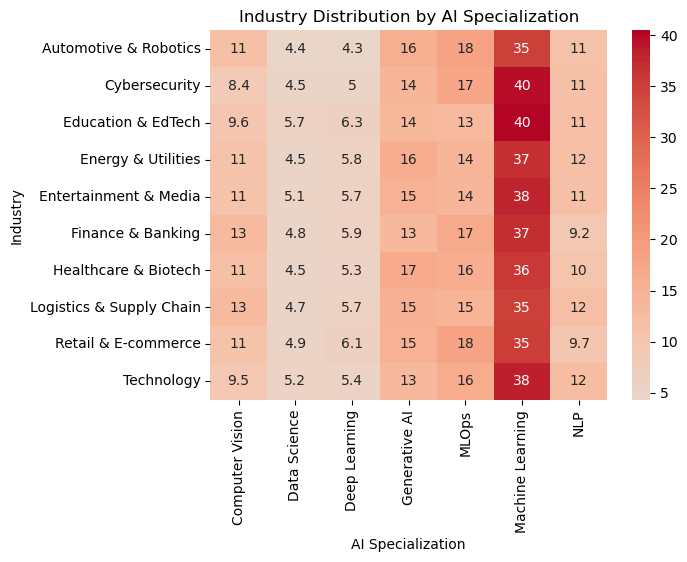

In [134]:
# This creates the table, now let's use a heatmap to visualize stuff
sns.heatmap(specialization_industry_counts, annot=True, cmap='coolwarm', center=0)
plt.title('Industry Distribution by AI Specialization')
plt.ylabel('Industry')
plt.xlabel('AI Specialization')

In [104]:
chisquare_table = pd.crosstab(
    more_popular_titles_postings['Company Industry'], more_popular_titles_postings['AI Specialization'])

chi2, p, dof, expected = chi2_contingency(chisquare_table)
print(f"Chi-square: {chi2:.2f}")
print(f"p-value: {p:.4g}")


Chi-square: 61.93
p-value: 0.2141


Machine Learning is concentrated everywhere. It's a broadly applicable AI specialization rather than an industry-sepcific one.
MLOps is more popular in Automotive & Robotics, Retail & E-commerce, Cybersecurity, and Finance & banking (13-18%), as the 2nd most popular category.
Generative AI and Computer Vision seem to be similar in size. 

Overall, although the prevalence of individual AI specializations varies slightly across industries, the overall distribution remains relatively consistent. Machine Learning represents the largest specialization across every industry, followed generally by MLOps and Generative AI, while Data Science and Deep Learning consistently represent smaller shares. This suggests that AI specialization in this dataset is not strongly concentrated by industry.

Now let's see if location affects specialization

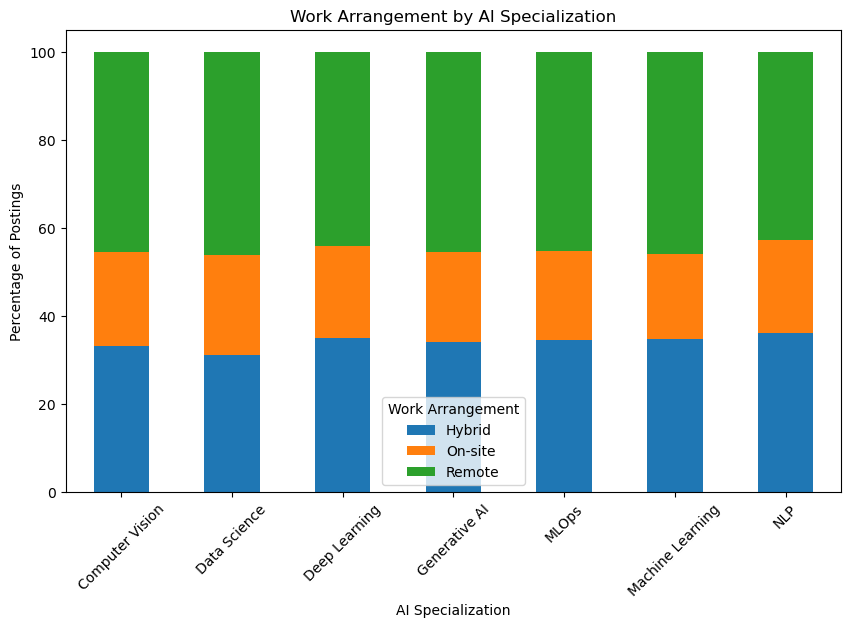

In [106]:
specialization_work_pct = pd.crosstab(
    more_popular_titles_postings['AI Specialization'],
    more_popular_titles_postings['Remote / Hybrid / On-site'],
    normalize='index'
) * 100

specialization_work_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

plt.ylabel('Percentage of Postings')
plt.xlabel('AI Specialization')
plt.title('Work Arrangement by AI Specialization')
plt.legend(title='Work Arrangement')
plt.xticks(rotation=45)
plt.show()

In [115]:
table = pd.crosstab(
    more_popular_titles_postings['AI Specialization'],
    more_popular_titles_postings['Remote / Hybrid / On-site']
)

chi2, p, dof, expected = chi2_contingency(table)
print(f"Chi-square: {chi2:.2f}")
print(f"p-value: {p:.4g}")

Chi-square: 8.71
p-value: 0.7279


Overall, work arrangement is seemingly not associated with AI specialization as the patterns of distribution amongs work arrangement by specialization remains very similar.

Now comes an interesting thing to cover, applicant volume.

we'll cover applicants by AI Specialization, then location, Experience Level, then company industry



In [116]:
applicants_by_specialization = (
    more_popular_titles_postings.groupby('AI Specialization')['Number of Applicants']
    .agg(['count', 'mean', 'median', 'std'])
    .sort_values('median', ascending=False)
)

applicants_by_specialization

,count,mean,median,std
AI Specialization,,,,
Data Science,423,228.749409,238.0,128.248550
Computer Vision,945,233.822222,235.0,128.733128
Deep Learning,485,227.993814,228.0,131.923993
MLOps,1389,226.089273,225.0,130.122473
Machine Learning,3245,224.265023,221.0,129.846167
NLP,961,220.392300,219.0,130.177247
Generative AI,1293,219.972158,212.0,129.603178


([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Computer Vision'),
  Text(1, 0, 'Deep Learning'),
  Text(2, 0, 'Machine Learning'),
  Text(3, 0, 'NLP'),
  Text(4, 0, 'Data Science'),
  Text(5, 0, 'Generative AI'),
  Text(6, 0, 'MLOps')])

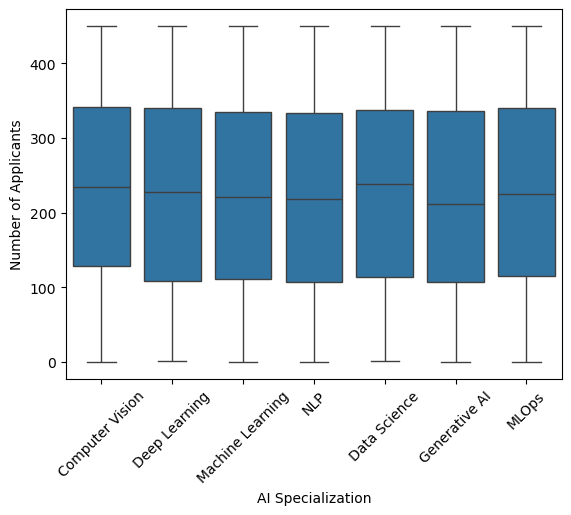

In [120]:
sns.boxplot(data=more_popular_titles_postings, x='AI Specialization', y='Number of Applicants')
plt.xticks(rotation=45)

From this, it looks like overall, applicant-volume distributions are very similar across AI specializations. Although small differences in median applicant counts exist, the distributions exhibit overlap and comparable ranges. It suggests AI specialization alone may not be strongly associated with applicant volume.


<Axes: xlabel='Remote / Hybrid / On-site', ylabel='Number of Applicants'>

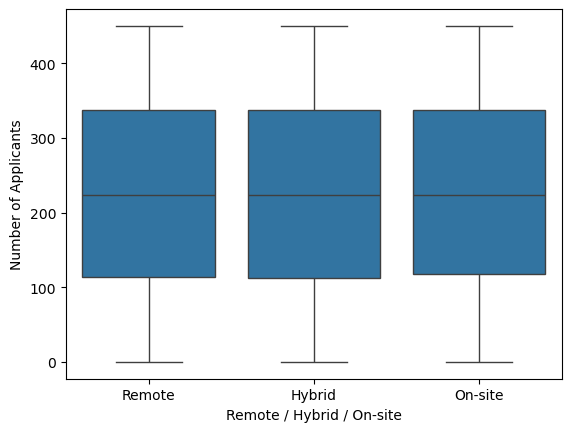

In [122]:
location_counts = more_popular_titles_postings.groupby('Remote / Hybrid / On-site')['Number of Applicants'].agg(['count', 'mean', 'median', 'std'])

sns.boxplot(data=more_popular_titles_postings, x='Remote / Hybrid / On-site', y='Number of Applicants')

Visually I don't see many differences. All three work arrangement have similar median,s interquartile ranges, and overall ranges. There's little visual evidence that work arrangement is associated with applicatn volume in this dataset.

In [123]:
applicant_summary = (
    more_popular_titles_postings.groupby([
        'AI Specialization',
        'Remote / Hybrid / On-site'
    ])['Number of Applicants']
    .median()
    .unstack()
)

applicant_summary

Remote / Hybrid / On-site,Hybrid,On-site,Remote
AI Specialization,,,
Computer Vision,230.0,235.0,239.0
Data Science,231.5,247.5,240.0
Deep Learning,223.5,245.0,225.5
Generative AI,214.0,218.0,207.5
MLOps,218.0,236.0,227.0
Machine Learning,225.0,209.0,220.0
NLP,235.0,207.0,217.0


After putting the table together, work arrangement doesn't really cause differences in applicant volume across AI specializations.

In [125]:
applicants_by_experience = (
    more_popular_titles_postings.groupby('Experience Level')['Number of Applicants']
    .agg(['count', 'mean', 'median', 'std'])
)
applicants_by_experience

,count,mean,median,std
Experience Level,,,,
Entry,1726,227.548088,229.0,131.313113
Mid,4399,223.993180,220.0,129.462997
Senior,2616,224.849006,225.0,129.480083


There appears to be a greater number of applicants in mid-level overall, but for the amount of postings on average doesn't seem to be any different.

In [128]:
industry_applicants = (
    more_popular_titles_postings.groupby('Company Industry')['Number of Applicants']
    .agg(['count', 'mean', 'median'])
    .sort_values('median', ascending=False)
)
industry_applicants

,count,mean,median
Company Industry,,,
Cybersecurity,881,227.275823,233.0
Entertainment & Media,877,231.155074,232.0
Automotive & Robotics,882,228.057823,229.5
Education & EdTech,855,221.770760,226.0
Finance & Banking,860,226.433721,226.0
Technology,872,226.397936,223.0
Energy & Utilities,868,227.052995,221.0
Healthcare & Biotech,882,222.654195,221.0
Logistics & Supply Chain,907,216.603087,216.0


In [133]:
industry_counts = more_popular_titles_postings['Company Industry'].value_counts()

valid_industries = industry_counts[
    industry_counts >= 50
].index

industry_df = more_popular_titles_postings[
    more_popular_titles_postings['Company Industry'].isin(valid_industries)
]

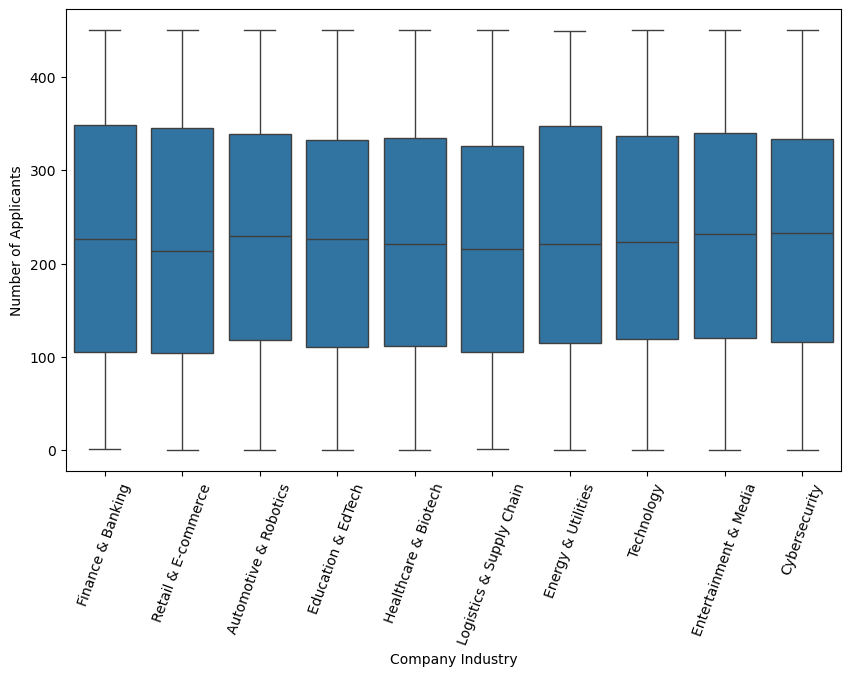

In [132]:
# now we do a boxplot with industry_df to see the distribution of applicants by industry
plt.figure(figsize=(10, 6))
sns.boxplot(data=industry_df, x='Company Industry', y='Number of Applicants')
plt.xticks(rotation=70)
plt.show()

All industries have similar paterns. First quarter is between around 105-120, median is around 215-230, third quarter is around 325-350, and the range is around 0-450. 
So within-industry applicant variation is much greater than between-industry variation.

Applicant volume does not appear to differ substantially across company industries. While median applicant counts vary slightly, all industries exhibit highly overlapping interquartile ranges and similar overall distributions. This suggests that company industry alone is unlikely to be a strong determinant of applicant volume in this dataset.

Applicant volume appears stable across several major categorical job characteristics. So specialization, industry, and work arrangement don't explain variations in applicant volume.